# Import Libraries and Set Filepaths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.decomposition import PCA
from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler #TODO remove this if it is not used
from sklearn.preprocessing import scale
from sklearn.manifold import TSNE
#from sklearn.cross_validation import train_test_split #TODO find this module
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [3]:
#Import the data
data_path = "/bgfs/dgomez/dgomez/Santiago/Intro to Programming 2026/UCI Data/TCGA-PANCAN-HiSeq-801x20531"

# Import the Data

In [4]:
rna_raw = pd.read_csv(data_path + "/data.csv")
labels = pd.read_csv(data_path + "/labels.csv")

### We can use Panda's .shape() and .head() to look at the first few rows of a dataframe

In [5]:
#change the name of this column
labels.rename(columns={"Unnamed: 0" : "Sample"}, inplace=True)
#make the first column of rna_raw the new index
labels.set_index("Sample", inplace=True)


print(f"Shape: {labels.shape}")
labels.head()

Shape: (801, 1)


,Class
Sample,
sample_0,PRAD
sample_1,LUAD
sample_2,PRAD
sample_3,PRAD
sample_4,BRCA


In [6]:
#change the name of this column
rna_raw.rename(columns={"Unnamed: 0" : "Sample"}, inplace=True)
#make the first column of rna_raw the new index
rna_raw.set_index("Sample", inplace=True)


print(f"Shape: {rna_raw.shape}")
rna_raw.head()

Shape: (801, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Sample,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


### add the class of the tumors by merging it into the RNA dataframe

In [7]:
rna_labeled = pd.concat([rna_raw, labels], axis=1)
#set the "index" of the dataframe to the "Class" column that we have just added
#note that the sample labels (ex. sample_1) are still stored in a column at the very end as "Unnamed: 0"
rna_labeled.set_index("Class", inplace=True)

#sort the dataframe by the index that we have just created
rna_labeled.sort_index(inplace=True)

#let's confirm that this manipulation worked
print(rna_labeled.shape)
rna_labeled.head()

(801, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Class,,,,,,,,,,,,,,,,,,,,,
BRCA,0.0,3.801873,5.025591,6.404150,9.564754,0.0,9.997688,1.025241,0.0,0.0,...,5.919628,8.507347,9.849333,8.184360,9.796564,11.607552,10.456272,9.949412,5.980037,0.000000
BRCA,0.0,3.277330,2.629846,6.000487,9.627027,0.0,8.375748,1.029559,0.0,0.0,...,6.152192,9.015499,10.244994,5.172335,9.788066,11.582057,11.098776,9.909158,5.494595,0.000000
BRCA,0.0,1.149975,0.462576,5.861427,10.092440,0.0,5.445833,1.045932,0.0,0.0,...,6.494526,9.549727,10.037602,6.636375,9.459339,10.109922,10.442394,9.574616,3.541862,0.000000
BRCA,0.0,4.538159,3.955722,6.259862,9.103243,0.0,6.918327,1.162726,0.0,0.0,...,7.102994,9.813018,10.629311,7.128757,10.409104,11.195225,11.169593,10.513451,6.729131,0.270828
BRCA,0.0,2.599770,2.562792,7.365491,10.462155,0.0,7.922370,0.000000,0.0,0.0,...,5.036873,8.267555,9.630254,5.531385,9.241642,11.459872,10.045882,9.091528,9.356654,0.000000


### Plot the raw data

<Axes: ylabel='Class'>

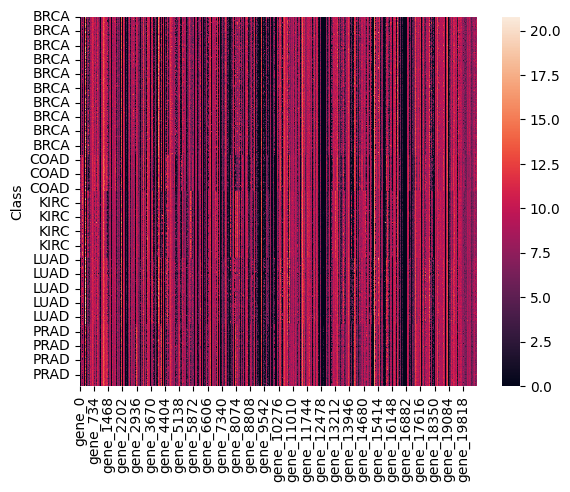

In [8]:
#if we try to plot the current dataframe, we will run into an error
sns.heatmap(rna_labeled)

NOTE: fixed the indexes above so now this acutally works fine and without a need for removing non-numerical columns. leaving in for now in case the artifact comes up again and we need to clarify a row / column

In [9]:
#this is because the "Unnamed: 0" column contains the sample information "sample_341"
#seaborn tries to convert this into a number to plot it throws an error becuase it is unabel to do so
#therefore we have to use only the numerical columns

#Pandas's columns are stored as an "Index"
print("\nColumns:")
print(rna_labeled.columns)
#And each column has a "datatype"
print("\nColumn Datatypes:")
print(rna_labeled.dtypes)
#There are two columns which are not numeric, both of which show the sample #s
print("\nHow many of each column:")
print(rna_labeled.dtypes.value_counts())


Columns:
Index(['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6',
       'gene_7', 'gene_8', 'gene_9',
       ...
       'gene_20521', 'gene_20522', 'gene_20523', 'gene_20524', 'gene_20525',
       'gene_20526', 'gene_20527', 'gene_20528', 'gene_20529', 'gene_20530'],
      dtype='object', length=20531)

Column Datatypes:
gene_0        float64
gene_1        float64
gene_2        float64
gene_3        float64
gene_4        float64
               ...   
gene_20526    float64
gene_20527    float64
gene_20528    float64
gene_20529    float64
gene_20530    float64
Length: 20531, dtype: object

How many of each column:
float64    20531
Name: count, dtype: int64


In [10]:
#note that the numerical columns are listed as "float64"
#we want to keep only these columns
rna = rna_labeled.select_dtypes(include="float64")

#note that we eliminated 2 numerical columns
print(f"before: {rna_labeled.shape}")
print(f"after: {rna.shape}")

#and that there are only numerical columns remaining
print(f"\nColumn datatypes count:\n{rna.dtypes.value_counts()}")


rna.head()

before: (801, 20531)
after: (801, 20531)

Column datatypes count:
float64    20531
Name: count, dtype: int64


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Class,,,,,,,,,,,,,,,,,,,,,
BRCA,0.0,3.801873,5.025591,6.404150,9.564754,0.0,9.997688,1.025241,0.0,0.0,...,5.919628,8.507347,9.849333,8.184360,9.796564,11.607552,10.456272,9.949412,5.980037,0.000000
BRCA,0.0,3.277330,2.629846,6.000487,9.627027,0.0,8.375748,1.029559,0.0,0.0,...,6.152192,9.015499,10.244994,5.172335,9.788066,11.582057,11.098776,9.909158,5.494595,0.000000
BRCA,0.0,1.149975,0.462576,5.861427,10.092440,0.0,5.445833,1.045932,0.0,0.0,...,6.494526,9.549727,10.037602,6.636375,9.459339,10.109922,10.442394,9.574616,3.541862,0.000000
BRCA,0.0,4.538159,3.955722,6.259862,9.103243,0.0,6.918327,1.162726,0.0,0.0,...,7.102994,9.813018,10.629311,7.128757,10.409104,11.195225,11.169593,10.513451,6.729131,0.270828
BRCA,0.0,2.599770,2.562792,7.365491,10.462155,0.0,7.922370,0.000000,0.0,0.0,...,5.036873,8.267555,9.630254,5.531385,9.241642,11.459872,10.045882,9.091528,9.356654,0.000000


<Axes: ylabel='Class'>

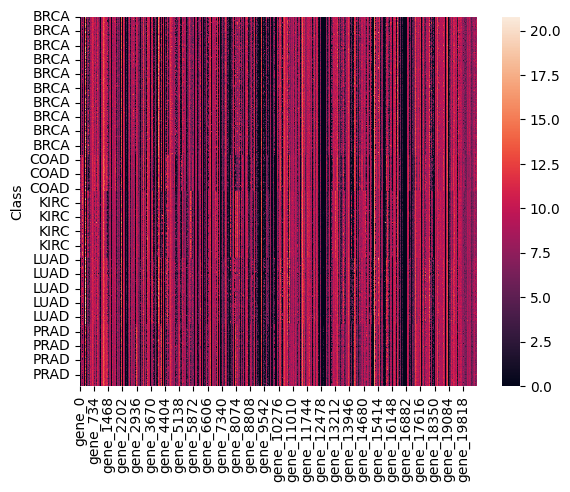

In [16]:
#now we can look at the "rna" dataframe, which is only numerical
sns.heatmap(rna)

From the heatmap:
Only a few columns (tumor type) and columns (genes) are labeled. The entire size is 800 samples x 20k genes.

Because the genes are randomly ordered, it is really hard to tell the differences between the tumors.

If we can order the genes, maybe they would fall into a few different categories:
- genes with low expression among all samples
- genes with high expression among all samples
- genes with different expression between tumor types

One method of sorting the genes into categories is with "hierarchichal clustering." 

/software/rhel9/manual/install/python/ondemand-jupyter-python3.11-2023.09/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/software/rhel9/manual/install/python/ondemand-jupyter-python3.11-2023.09/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


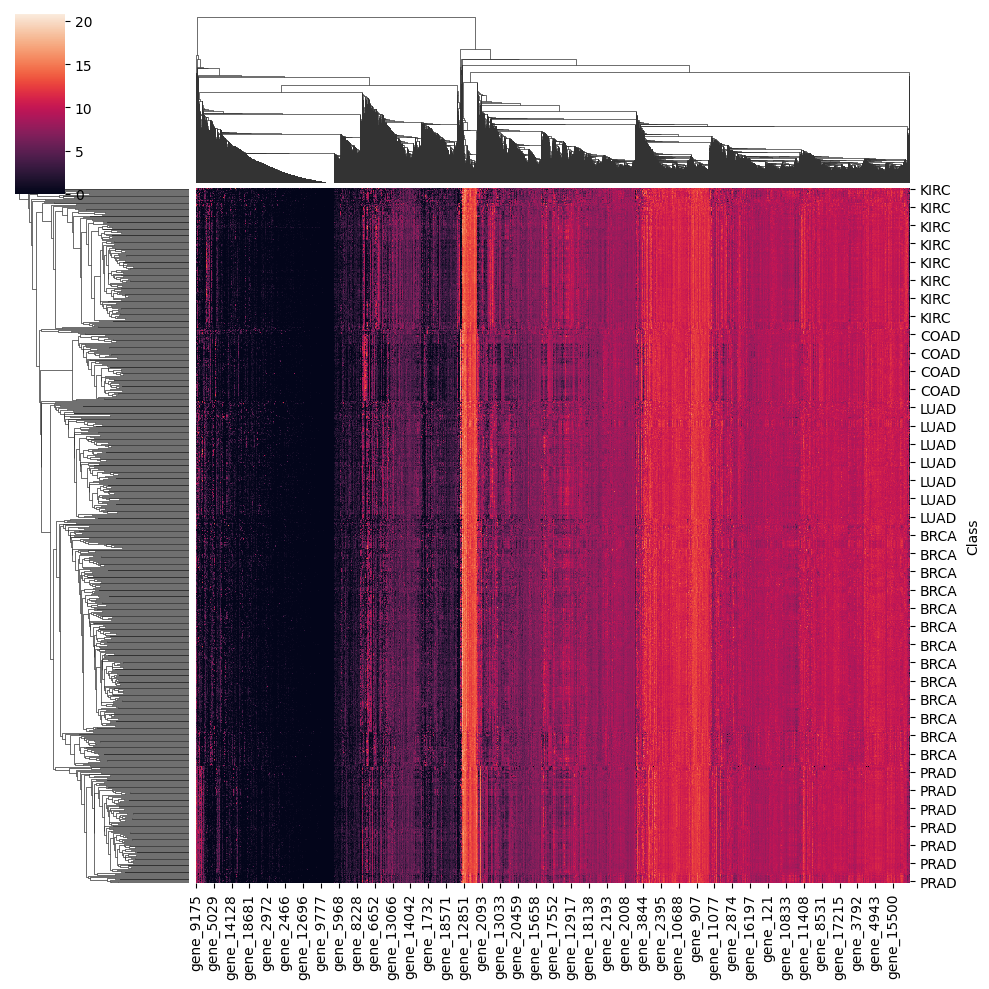

In [17]:
sns.clustermap(rna)

With the genes sorted into clusters, we can tell that some genes have low / no expression while others are highly expressed.

The differences between tumor types are not readily apparent. If you look closely, you can start to make them out. For example, around gene_2093, there are some PRAD-specific genes

Also, the algorithm was able to separate tumor types! Even though we sorted the index before (for the heatmap above), the hierarchichal clustering separated these on its own. Note it may not be 100% accurate, but from the small sample of "Class" that are labeled on the plot, they are all within their class.

# Dimensional Reduction with PCA

In [13]:
#gather the raw RNA again
x_raw = rna_raw #note that this does not have the label information integrated and everything is numerical
y = labels

### Log Transform the Dataframe

In [14]:
#Taking the log2 reduces the variance in the 
x_log = np.log2(x_raw+1)
x_log.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Sample,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,1.593215,2.092724,2.695657,3.515006,0.0,3.031250,0.670723,0.0,0.0,...,2.567232,3.203241,3.422706,3.039144,3.339111,3.700788,3.412882,3.310533,2.652317,0.0
sample_1,0.0,0.671504,1.372072,3.102013,3.409121,0.0,2.966440,0.000000,0.0,0.0,...,2.483718,3.057254,3.425047,2.859291,3.229836,3.773422,3.525700,3.378214,1.629552,0.0
sample_2,0.0,2.173690,2.413377,2.978523,3.442377,0.0,2.994965,0.538633,0.0,0.0,...,2.614760,3.190160,3.573937,2.678434,3.447790,3.328442,3.431404,3.471249,1.423859,0.0
sample_3,0.0,2.221450,2.461437,2.937169,3.484935,0.0,3.144597,0.520932,0.0,0.0,...,2.823049,3.291745,3.477874,3.313653,3.406157,3.631417,3.418839,3.417429,2.101651,0.0
sample_4,0.0,1.870164,1.934157,2.914460,3.424689,0.0,2.919715,0.444648,0.0,0.0,...,2.806537,3.306178,3.507641,3.032306,3.439212,3.691807,3.353006,3.386975,2.611260,0.0


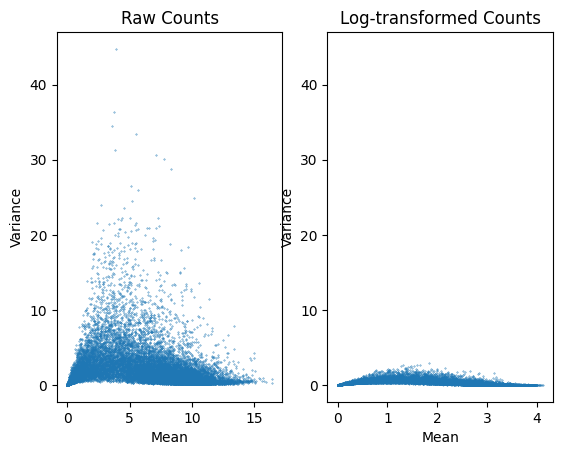

In [15]:
fig, [ax1, ax2] = plt.subplots(ncols=2)
ax1.scatter(x_raw.mean(), x_raw.var(),
           s = 0.1)
ax1.set_title("Raw Counts")
y_axis_limits = ax1.get_ylim()

ax2.scatter(x_log.mean(), x_log.var(),
            s = 0.1)
ax2.set_title("Log-transformed Counts")
#have the y axis match the raw counts plot for easier comparison
ax2.set_ylim(y_axis_limits)


for ax in [ax1, ax2]:
    ax.set_xlabel("Mean")
    ax.set_ylabel("Variance")

## Dimensionality Reduction with PCA

In [ ]:
#skeleton code:
#run PCA
#with Seaborn, plot first ~5 principal components

#look at the % variance explained for each principal component (elbow plot)

#look at the top genes from each principal component
#do they have biological relevance??


#In the slides (but not on student's code): train a model on BOTH PCAs and Raw counts and see which performs better.

# Train the Models

## Train-test split

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

# X_train, X_test, y_train, y_test = train_test_split(
#     X_selected, y, test_size=0.3, random_state=42, stratify=y
# )

#NOTE: this will be done BEFOREHAND, in a different notebook, 
#and the students will be given the testing portion of (only around 30% of the data)

## Scale the Data

SciKit Documentation for this function:
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html#sklearn.preprocessing.scale

"Removing the mean and scaling to unit variance"
For every column, the mean is calculated. This is the average gene expression across all columns for the mean. After subtracting the mean from all of the genes, we will have a sum of 0.

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X_train)
x_sca = scaler.transform(X_test)

In [ ]:
print("Features standardized (mean=0, std=1)")
print(f"Training data - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

In [23]:
# SVM without PCA
# print("Training SVM (RBF kernel)...")
# svm_no_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
# svm_no_pca.fit(X_train_scaled, y_train)

# y_pred_svm_no_pca = svm_no_pca.predict(X_test_scaled)
# y_pred_proba_svm_no_pca = svm_no_pca.predict_proba(X_test_scaled)[:, 1]

# svm_acc_no_pca = accuracy_score(y_test, y_pred_svm_no_pca)
# svm_auc_no_pca = roc_auc_score(y_test, y_pred_proba_svm_no_pca)

# print(f"SVM Accuracy: {svm_acc_no_pca:.4f}")
# print(f"SVM AUC-ROC: {svm_auc_no_pca:.4f}")

#repeat for SVM with PCA

# Summary and ToDo

In [ ]:
#Slides will go over all of the manipulations:
#log, scaling, PCA, selecting variable genes,
#train-test split, training of models: SVM, random forest or decision tree

#Students will be provided with the testing dataset (30% of samples)
#they will do the log, sclaing, and PCA
#they will be provided with a trained model
#they will then test this using accuracy_score and roc_auc_score and plot the ROC.
